# QuantGAN Evaluation

This notebook demonstrates how to evaluate a trained QuantGAN model.

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

from quantgan import (
    DataConfig,
    PreprocessConfig,
    DatasetConfig,
    ModelConfig,
    TrainConfig,
)
from quantgan.data import DefeatBetaSource, LambertWPreprocessor
from quantgan.evaluation import PaperEvaluator, Plotter
from quantgan.utils import set_all_seeds, build_and_load_generator, generate_M_paths_raw

print("TensorFlow:", tf.__version__)



2026-02-23 22:41:40.783450: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 22:41:40.783736: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 22:41:40.818610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 22:41:41.860569: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

TensorFlow: 2.20.0


## 1. Configuration and Data Loading

In [3]:
# Configuration
data_cfg = DataConfig()
pre_cfg = PreprocessConfig()
ds_cfg = DatasetConfig()
model_cfg = ModelConfig(
    generator_type="pure_tcn",  # Must match trained model
)
train_cfg = TrainConfig()

# Evaluation settings
WEIGHTS_PATH = "./quantgan_outputs_wgangp/bestG_pure_tcn_seed0_epoch180.weights.pkl"
M = 500  # Number of paths to generate
Ttilde = 4000  # Length of generated paths
S_lags = 250  # Lags for ACF/leverage plots
SEED = 0

set_all_seeds(SEED)

In [4]:
# Load real data
src = DefeatBetaSource(data_cfg)
df = src.fetch()
close = df["Close"].dropna()
real_series = src.log_returns_from_close(df)
T_real = len(real_series)

print(f"[DATA] {data_cfg.ticker} T={T_real} "
      f"mean={float(real_series.mean()):.6g} std={float(real_series.std()):.6g} "
      f"kurt={float(kurtosis(real_series, fisher=False, bias=False)):.3f}")

[DATA] Loaded from cache: data/defeatbeta_SPY_2009-05-01_2018-12-31_1d.csv
[DATA] SPY T=2433 mean=0.000429533 std=0.00962302 kurt=6.975


In [5]:
# Fit preprocessor on real data
pre = LambertWPreprocessor(pre_cfg).fit(real_series)
print("[PRE] state:", pre.summary())

[PRE] state: {'use_lambert': True, 'renorm_after_lambert': True, 'r_mean': 0.0004295334295416232, 'r_std': 0.009623020589921769, 'lam_mu': 0.036145429573328836, 'lam_sigma': 0.6655962445571071, 'delta_hat': 0.24627699358959143, 'u_mean': -0.0225337046505423, 'u_std': 0.9997461160580793, 'u_uclip': 2.8060439325483437}


## 2. Load Trained Model

In [6]:
# Build and load generator
netG = build_and_load_generator(
    model_cfg=model_cfg,
    window_len=ds_cfg.window_len,
    weights_path=WEIGHTS_PATH,
    seed=SEED,
)

print(f"[MODEL] Generator loaded: {model_cfg.generator_type}")
print(f"[MODEL] Parameters: {netG.count_params():,}")

2026-02-23 22:41:56.797027: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[MODEL] Generator loaded: pure_tcn
[MODEL] Parameters: 210,161


## 3. Generate Synthetic Paths

In [7]:
# Generate M paths of length Ttilde
fake_paths = generate_M_paths_raw(
    netG=netG,
    preproc=pre,
    M=M,
    Ttilde=Ttilde,
    window_len=ds_cfg.window_len,
    z_dim=model_cfg.z_dim,
    batch=50,
    seed=SEED,
)

print(f"[GENERATED] shape={fake_paths.shape}")
print(f"[GENERATED] mean={float(fake_paths.mean()):.6g} "
      f"std={float(fake_paths.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths.reshape(-1), fisher=False, bias=False)):.3f}")

[GENERATED] shape=(500, 4000)
[GENERATED] mean=0.000426096 std=0.00896121 kurt=8.308


## 5. Evaluate with Paper Metrics

In [8]:
# Compute paper score
evaluator = PaperEvaluator(
    real_series=real_series,
    preproc=pre,
    train_cfg=train_cfg,
    dy_base_t=len(real_series),
)

paper_score, parts = evaluator.paper_score(fake_paths)

print(f"\n=== PAPER SCORE: {paper_score:.6g} ===")
print(f"ACF(r):   {parts['acf_x']:.4g}")
print(f"ACF(|r|): {parts['acf_abs']:.4g}")
print(f"ACF(r²):  {parts['acf_sq']:.4g}")
print(f"Leverage: {parts['lev']:.4g}")
print(f"DY sum:   {parts['dy_sum']:.4g}")
print(f"DY by lag: {parts['dy_by_t']}")


=== PAPER SCORE: 0.124142 ===
ACF(r):   0.02266
ACF(|r|): 0.02422
ACF(r²):  0.02254
Leverage: 0.3201
DY sum:   90.82
DY by lag: {1: 18.594909935726104, 5: 16.70630909856274, 20: 20.026896639684796, 100: 35.487548467081474}


## 6. Visualizations

In [9]:
# Create plotter
plotter = Plotter(show=True, save=False)

# For plotting, slice to match real data length
fake_for_plots = fake_paths[:, :T_real]

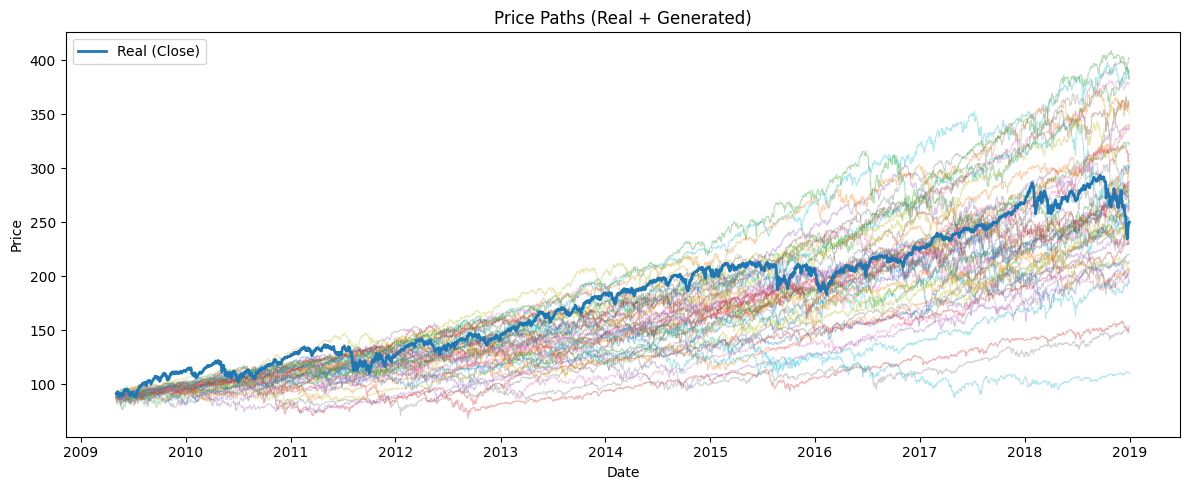

In [10]:
# Plot price paths
plotter.plot_price_paths(
    close_series=close,
    fake_logret_paths=fake_for_plots,
    n_paths=50,
    title="Price Paths (Real + Generated)",
)

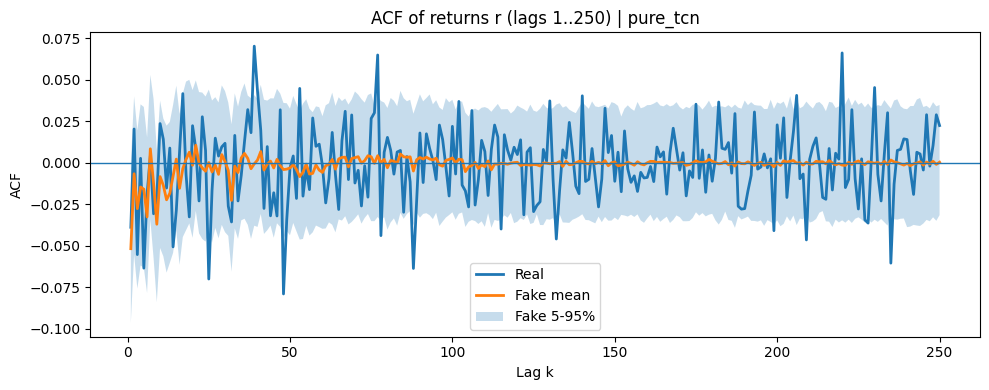

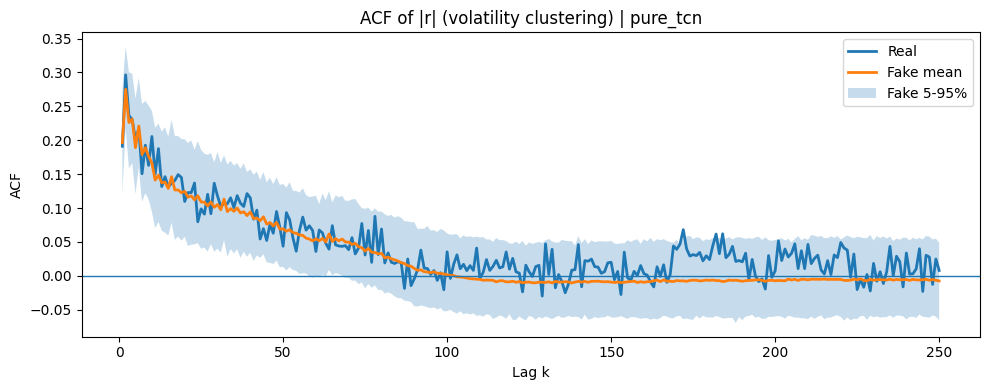

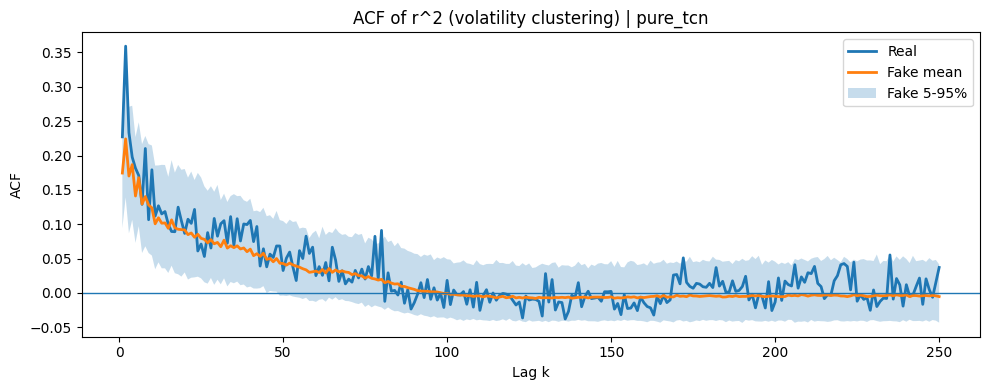

In [11]:
# Plot ACF bundle
plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f" | {model_cfg.generator_type}",
)

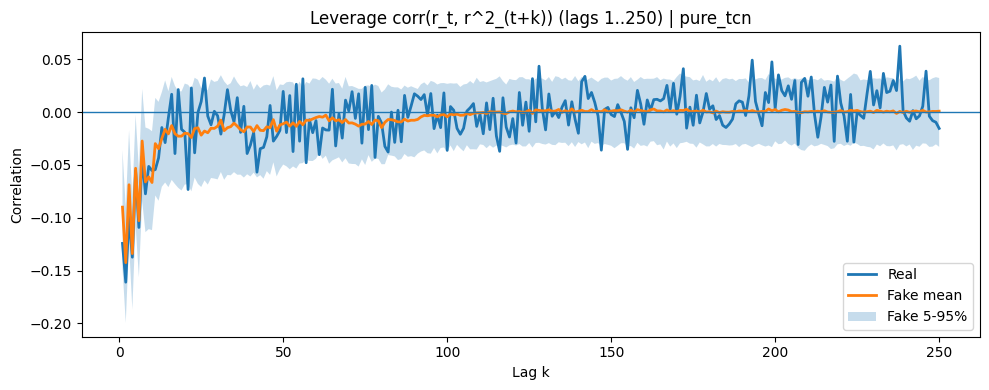

In [12]:
# Plot leverage
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots,
    S=S_lags,
    title_suffix=f" | {model_cfg.generator_type}",
)

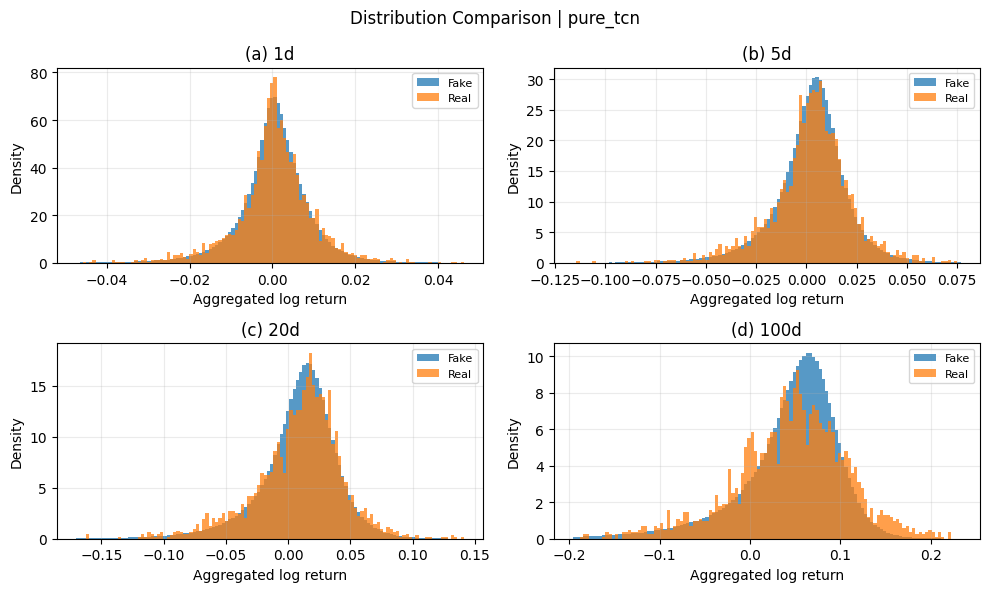

In [13]:
# Plot histogram panel
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots,
    t_lags=(1, 5, 20, 100),
    title=f"Distribution Comparison | {model_cfg.generator_type}",
)

---
## SVNN Evaluation

In [15]:
# SVNN configuration
model_cfg_svnn = ModelConfig(
    generator_type="svnn",
    g_ch=60,
    g_ch_hidden=60,
)

WEIGHTS_PATH_SVNN = "./quantgan_outputs_wgangp/bestG_svnn_seed0_epoch220.weights.pkl"

set_all_seeds(SEED)


In [16]:
# Build and load SVNN generator
netG_svnn = build_and_load_generator(
    model_cfg=model_cfg_svnn,
    window_len=ds_cfg.window_len,
    weights_path=WEIGHTS_PATH_SVNN,
    seed=SEED,
)
print(f"[SVNN] Generator loaded: {model_cfg_svnn.generator_type}")
print(f"[SVNN] Parameters: {netG_svnn.count_params():,}")


[SVNN] Generator loaded: svnn
[SVNN] Parameters: 119,282


In [17]:
# Generate SVNN paths
fake_paths_svnn = generate_M_paths_raw(
    netG=netG_svnn,
    preproc=pre,
    M=M,
    Ttilde=Ttilde,
    window_len=ds_cfg.window_len,
    z_dim=model_cfg_svnn.z_dim,
    batch=50,
    seed=SEED,
)
print(f"[SVNN] shape={fake_paths_svnn.shape}")
print(f"[SVNN] mean={float(fake_paths_svnn.mean()):.6g} std={float(fake_paths_svnn.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths_svnn.reshape(-1), fisher=False, bias=False)):.3f}")


[SVNN] shape=(500, 4000)
[SVNN] mean=0.000410987 std=0.00907149 kurt=7.566


In [20]:
# SVNN paper score
paper_score_svnn, parts_svnn = evaluator.paper_score(fake_paths_svnn)
print(f"\n=== SVNN PAPER SCORE: {paper_score_svnn:.6g} ===")
print(f"ACF(r):   {parts_svnn['acf_x']:.4g}")
print(f"ACF(|r|): {parts_svnn['acf_abs']:.4g}")
print(f"ACF(r²):  {parts_svnn['acf_sq']:.4g}")
print(f"Leverage: {parts_svnn['lev']:.4g}")
print(f"DY sum:   {parts_svnn['dy_sum']:.4g}")
print(f"DY by lag: {parts_svnn['dy_by_t']}")



=== SVNN PAPER SCORE: 0.124926 ===
ACF(r):   0.02283
ACF(|r|): 0.02557
ACF(r²):  0.02572
Leverage: 0.3229
DY sum:   74.11
DY by lag: {1: 18.04766460130407, 5: 14.945921495652776, 20: 17.541514691301913, 100: 23.572746388461127}


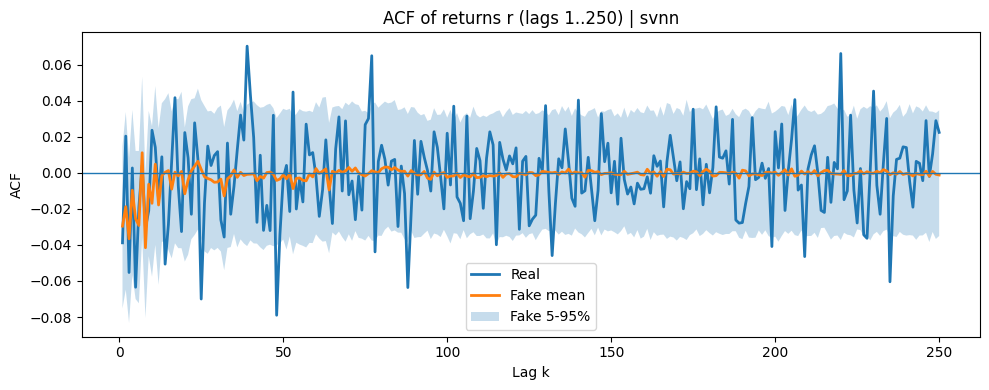

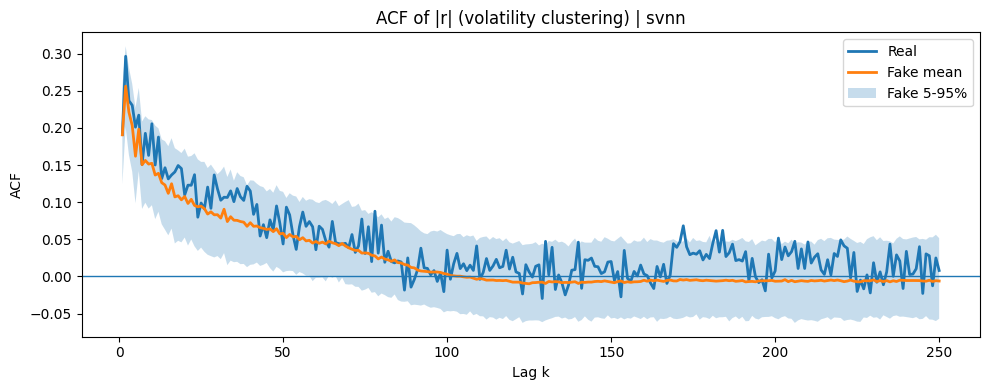

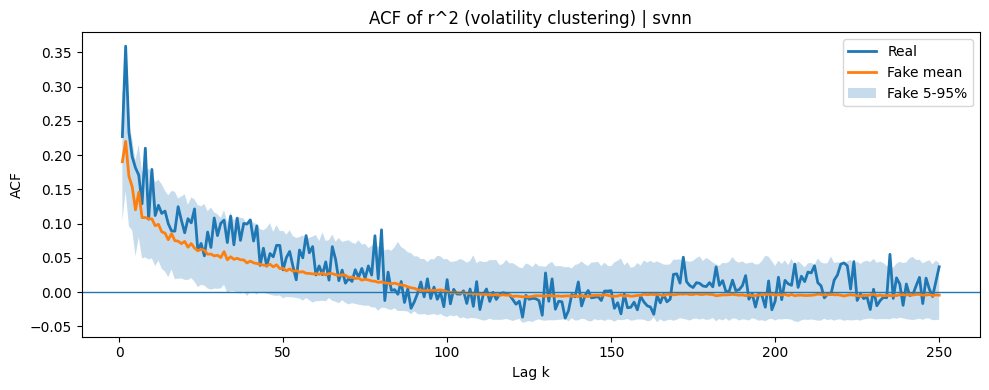

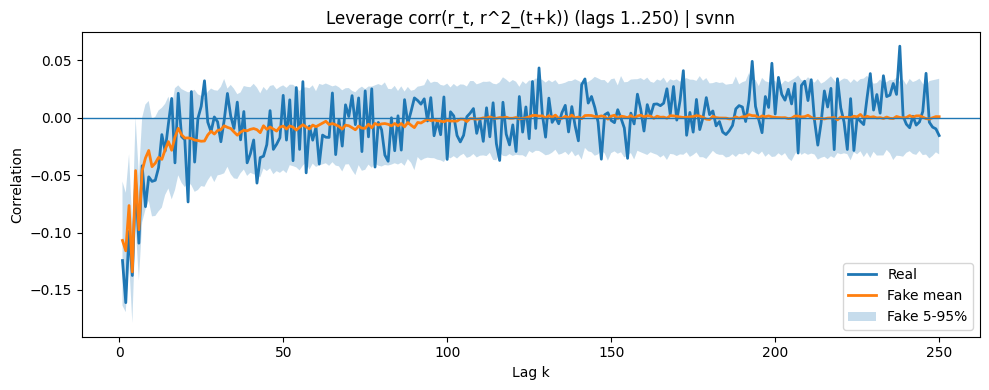

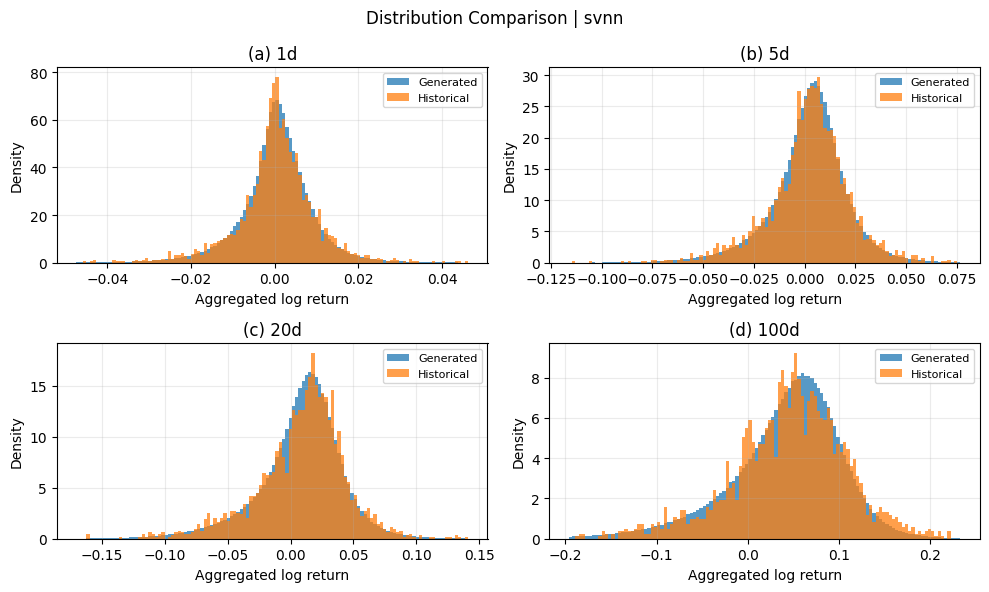

In [23]:
# SVNN plots

fake_for_plots_svnn = fake_paths_svnn[:, :T_real]

plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=" | svnn",
)
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    S=S_lags,
    title_suffix=" | svnn",
)
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_svnn,
    t_lags=(1, 5, 20, 100),
    title="Distribution Comparison | svnn",
    label_fake="Generated",
    label_real="Historical",
)


---
## GARCH(1,1) Baseline

In [24]:
import math
from scipy.stats import wasserstein_distance
try:
    from arch import arch_model
except ImportError:
    raise ImportError("Install via: pip install arch")


In [25]:
# Fit GARCH(1,1) on real data
_scale = 100.0
_y_fit = _scale * real_series

_am = arch_model(_y_fit, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
_res = _am.fit(disp="off", update_freq=0)
_params = _res.params

_mu_hat    = float(_params.get("mu", _params.get("Const")))
_omega_hat = float(_params.get("omega"))
_alpha_hat = float(_params.get("alpha[1]"))
_beta_hat  = float(_params.get("beta[1]"))

_mu_fit = _mu_hat / _scale
_omega  = _omega_hat / (_scale ** 2)
_alpha  = _alpha_hat
_beta   = _beta_hat

print(f"[GARCH] mu={_mu_fit:.6g}  omega={_omega:.6g}  alpha={_alpha:.6g}  beta={_beta:.6g}")
print(f"[GARCH] persistence alpha+beta = {_alpha+_beta:.6g}")


[GARCH] mu=0.000728062  omega=3.05501e-06  alpha=0.149108  beta=0.820731
[GARCH] persistence alpha+beta = 0.969838


In [26]:
# Simulate GARCH(1,1) paths
def _sim_garch11(mu, omega, alpha, beta, nobs, burn=2000, seed=None):
    rng = np.random.default_rng(seed)
    total = nobs + burn
    eps = rng.standard_normal(total)
    r = np.zeros(total); s2 = np.zeros(total)
    s2[0] = omega / max(1e-12, 1.0 - alpha - beta) if (alpha+beta) < 0.999 else float(np.var(real_series))
    s2[0] = max(s2[0], 1e-18)
    r[0] = mu + math.sqrt(s2[0]) * eps[0]
    for t in range(1, total):
        s2[t] = max(omega + alpha*(r[t-1]-mu)**2 + beta*s2[t-1], 1e-18)
        r[t]  = mu + math.sqrt(s2[t]) * eps[t]
    return r[burn:], s2[burn:]

_base_rng = np.random.default_rng(SEED)
_seeds = _base_rng.integers(0, 2**32-1, size=M, dtype=np.uint32)
fake_paths_garch = np.zeros((M, Ttilde))
for _i in range(M):
    fake_paths_garch[_i], _ = _sim_garch11(_mu_fit, _omega, _alpha, _beta,
                                             nobs=Ttilde, burn=2000, seed=int(_seeds[_i]))

print(f"[GARCH] shape={fake_paths_garch.shape}")
print(f"[GARCH] mean={float(fake_paths_garch.mean()):.6g} std={float(fake_paths_garch.std()):.6g} "
      f"kurt={float(kurtosis(fake_paths_garch.reshape(-1), fisher=False, bias=False)):.3f}")


[GARCH] shape=(500, 4000)
[GARCH] mean=0.000725007 std=0.010067 kurt=8.783


In [28]:
DRIFT_ALIGN = True
# Drift alignment GARCH
if DRIFT_ALIGN:
    drift_shift_garch = float(real_series.mean() - fake_paths_garch.mean())
    fake_paths_garch_aligned = fake_paths_garch + drift_shift_garch
    print(f"[GARCH DRIFT] shift={drift_shift_garch:.6g}")
else:
    fake_paths_garch_aligned = fake_paths_garch

fake_for_plots_garch = fake_paths_garch_aligned[:, :T_real]


[GARCH DRIFT] shift=-0.000295474


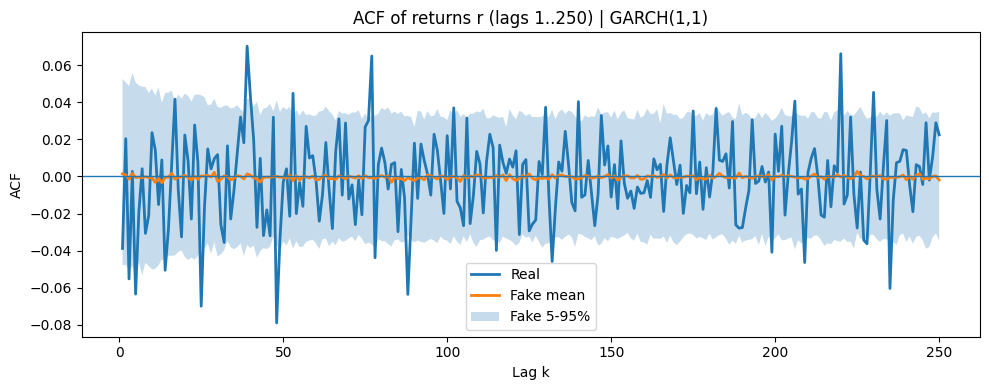

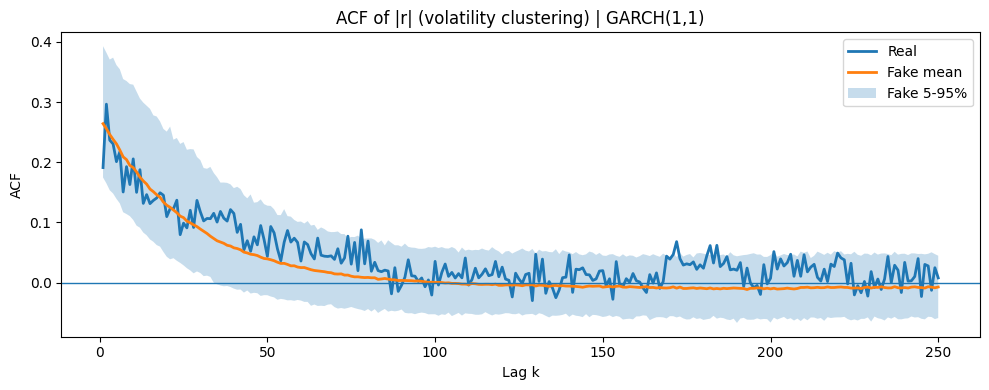

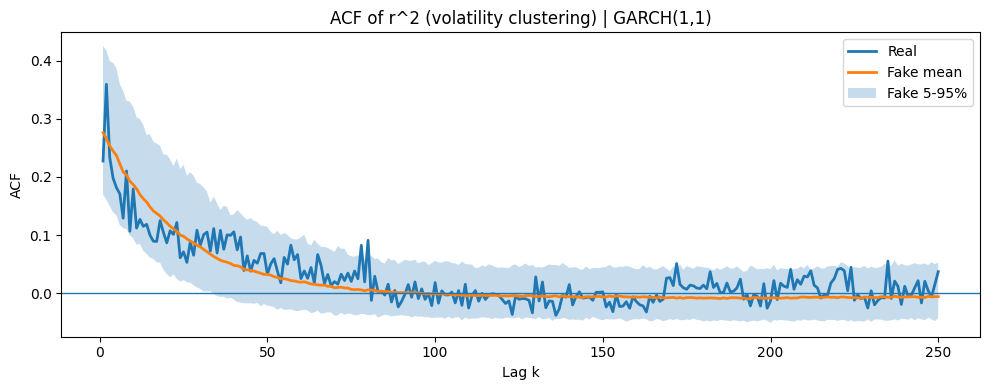

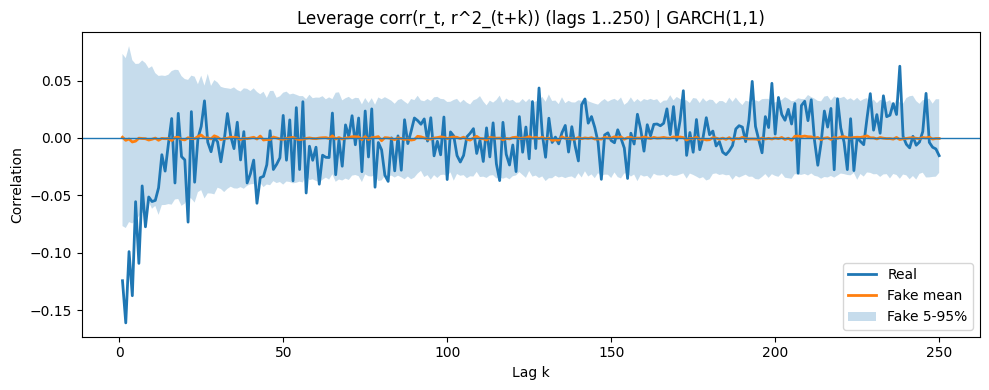

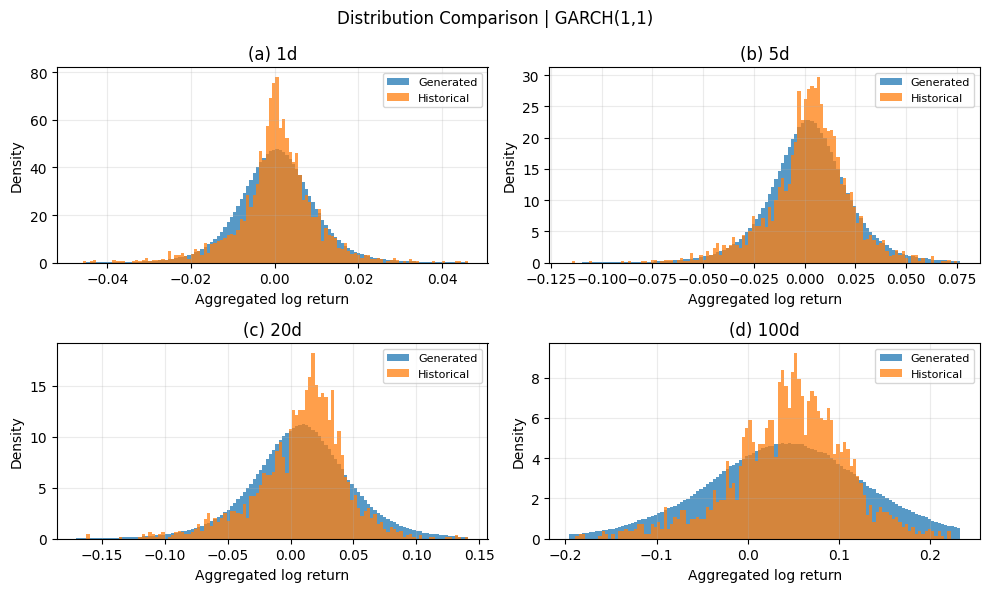

In [29]:
# GARCH plots
plotter.plot_acf_bundle(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=" | GARCH(1,1)",
)
plotter.plot_leverage(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    S=S_lags,
    title_suffix=" | GARCH(1,1)",
)
plotter.plot_hist_panel(
    real_r=real_series,
    fake_paths=fake_for_plots_garch,
    t_lags=(1, 5, 20, 100),
    title="Distribution Comparison | GARCH(1,1)",
    label_fake="Generated",
    label_real="Historical",
)
